In [164]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("./blog.mplstyle")

# plt.rcParams["font.monospace"] = ["FreeMono"]

DATA_DIR = "../data/"

In [165]:
df = pd.read_csv(DATA_DIR + "caiso_combined.csv", parse_dates=["datetime"])

df

,datetime,area,load
0,2021-01-01 00:00:00,caiso,21447.230233
1,2021-01-01 01:00:00,caiso,20582.803317
2,2021-01-01 02:00:00,caiso,19930.106541
3,2021-01-01 03:00:00,caiso,19621.308843
4,2021-01-01 04:00:00,caiso,19610.888536
...,...,...,...
37938,2025-04-30 19:00:00,caiso,26861.659560
37939,2025-04-30 20:00:00,caiso,27302.432181
37940,2025-04-30 21:00:00,caiso,26492.314470
37941,2025-04-30 22:00:00,caiso,24844.691313


In [166]:
# add datetime-derived indicators

# hour column is 1-24, convert to 0-23
df["date"] = df["datetime"].dt.date
df["hour"] = df["datetime"].dt.hour
df["dow"] = df["datetime"].dt.dayofweek
df["doy"] = df["datetime"].dt.dayofyear
df["month"] = df["datetime"].dt.month
df["year"] = df["datetime"].dt.year
# weekend indicator
df["is_weekend"] = df["dow"].isin([5, 6]).astype(int)
# df["week"] = df["datetime"].dt.isocalendar().week

In [167]:
# # filter to 2022-2024
# df = df[df["year"].isin([2022, 2023, 2024])].copy()

In [168]:
df

,datetime,area,load,date,hour,dow,doy,month,year,is_weekend
0,2021-01-01 00:00:00,caiso,21447.230233,2021-01-01,0,4,1,1,2021,0
1,2021-01-01 01:00:00,caiso,20582.803317,2021-01-01,1,4,1,1,2021,0
2,2021-01-01 02:00:00,caiso,19930.106541,2021-01-01,2,4,1,1,2021,0
3,2021-01-01 03:00:00,caiso,19621.308843,2021-01-01,3,4,1,1,2021,0
4,2021-01-01 04:00:00,caiso,19610.888536,2021-01-01,4,4,1,1,2021,0
...,...,...,...,...,...,...,...,...,...,...
37938,2025-04-30 19:00:00,caiso,26861.659560,2025-04-30,19,2,120,4,2025,0
37939,2025-04-30 20:00:00,caiso,27302.432181,2025-04-30,20,2,120,4,2025,0
37940,2025-04-30 21:00:00,caiso,26492.314470,2025-04-30,21,2,120,4,2025,0
37941,2025-04-30 22:00:00,caiso,24844.691313,2025-04-30,22,2,120,4,2025,0


In [169]:
df_2022 = df[df["year"] == 2022].copy()
df_2023 = df[df["year"] == 2023].copy()
df_2024 = df[df["year"] == 2024].copy()

In [170]:
df_daily = df.groupby(["date", "dow"])["load"].mean().reset_index()
# add datetime with hour set to 12:00
df_daily["datetime"] = pd.to_datetime(df_daily["date"]) + pd.to_timedelta(12, unit="h")

df_daily

,date,dow,load,datetime
0,2021-01-01,4,21014.041051,2021-01-01 12:00:00
1,2021-01-02,5,21735.531650,2021-01-02 12:00:00
2,2021-01-03,6,21253.754596,2021-01-03 12:00:00
3,2021-01-04,0,23401.974029,2021-01-04 12:00:00
4,2021-01-05,1,23556.944706,2021-01-05 12:00:00
...,...,...,...,...
1576,2025-04-26,5,22292.514674,2025-04-26 12:00:00
1577,2025-04-27,6,21731.324807,2025-04-27 12:00:00
1578,2025-04-28,0,22866.136073,2025-04-28 12:00:00
1579,2025-04-29,1,23380.302566,2025-04-29 12:00:00


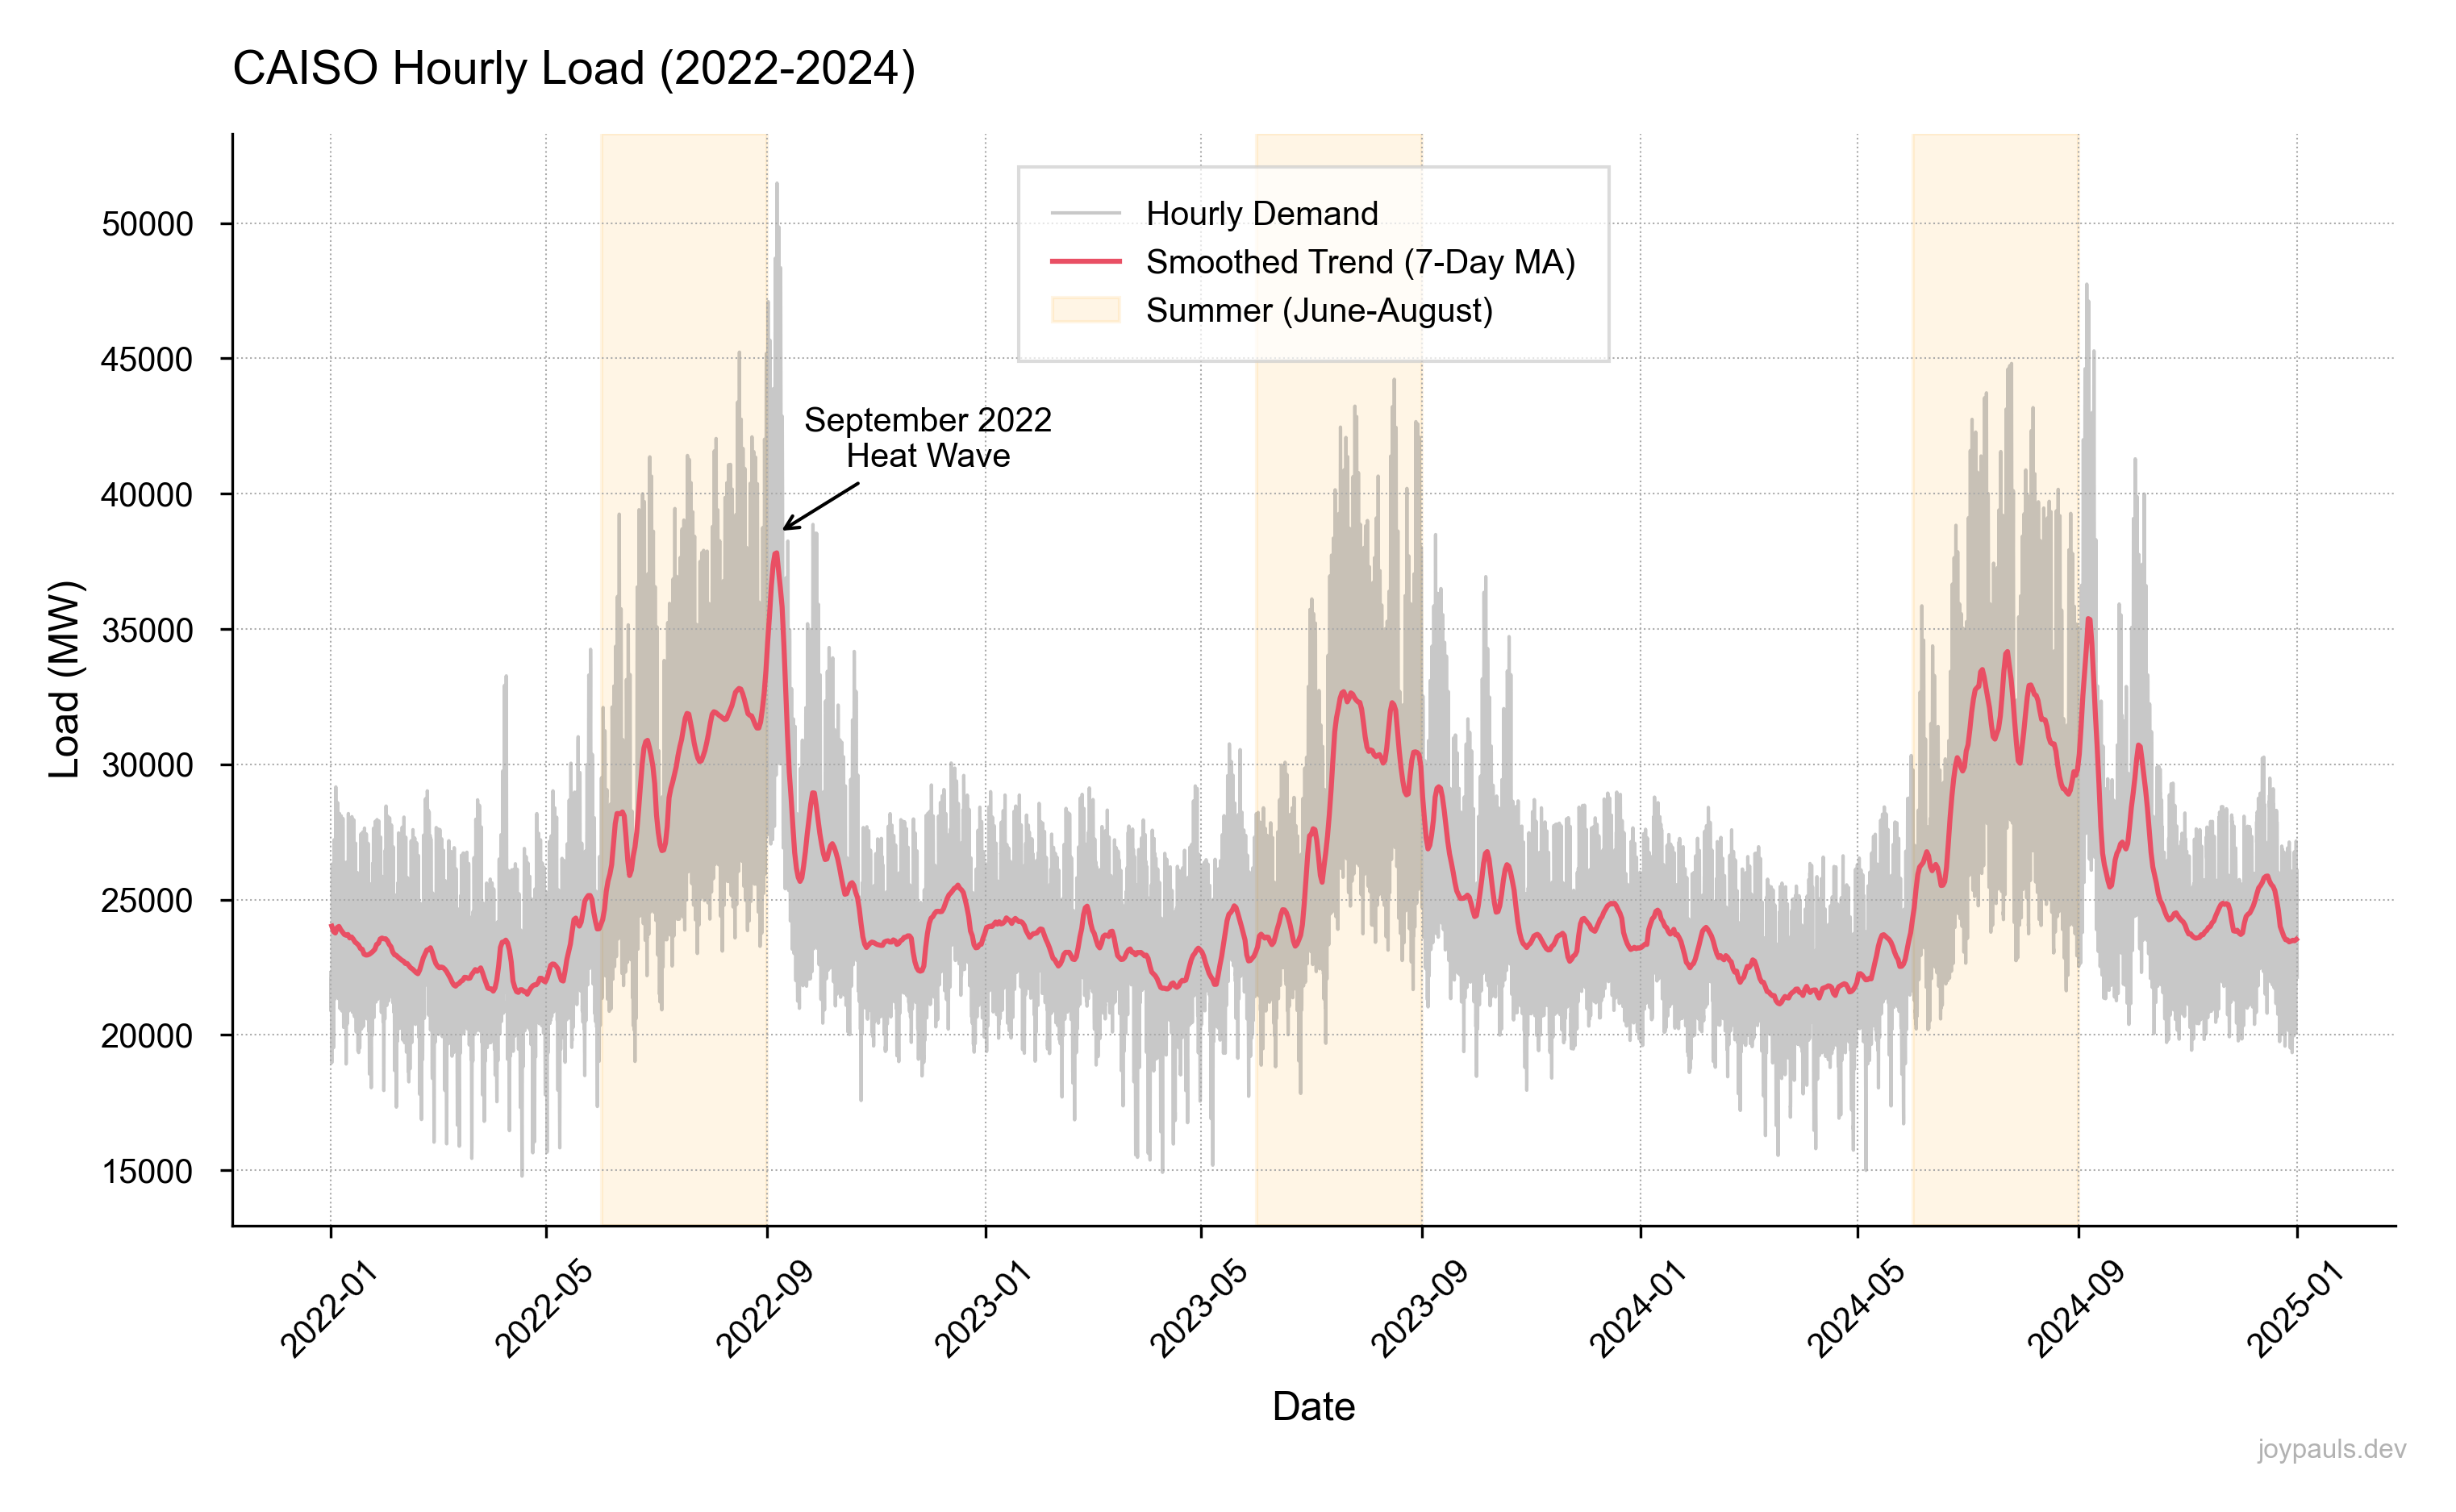

In [182]:
# caclculate centered moving average
df_daily["load_ma"] = df_daily["load"].rolling(window=7, min_periods=1, center=True).mean()

# filter to 2022-2024
df3 = df[df["year"].isin([2022, 2023, 2024])].copy()
df_daily3 = df_daily[df_daily["datetime"].dt.year.isin([2022, 2023, 2024])].copy()

# # join to original df
# detrended_df = df[["datetime", "date", "load"]].merge(df_daily[["date", "load_ma"]], on="date", how="left")
# detrended_df["load_detrended"] = detrended_df["load"] - detrended_df["load_ma"]

# plot line line chart
plt.figure(figsize=(10, 6))

plt.plot(df3["datetime"], df3["load"], alpha=0.3, label="Hourly Demand", linewidth=1, zorder=1)
plt.plot(df_daily3["datetime"], df_daily3["load_ma"], label="Smoothed Trend (7-Day MA)", linewidth=1.5, zorder=2)

# highlight summers
plt.axvspan(pd.to_datetime("2022-06-01"), pd.to_datetime("2022-09-01"), color="orange", alpha=0.1, label="Summer (June-August)", zorder=0)
plt.axvspan(pd.to_datetime("2023-06-01"), pd.to_datetime("2023-09-01"), color="orange", alpha=0.1, zorder=0)
plt.axvspan(pd.to_datetime("2024-06-01"), pd.to_datetime("2024-09-01"), color="orange", alpha=0.1, zorder=0)

# annotate spike in september 2022 with centered text
plt.annotate("September 2022\nHeat Wave",
             xy=(pd.to_datetime("2022-09-06"), 38500),
             xytext=(pd.to_datetime("2022-11-30"), 41000),
             arrowprops=dict(arrowstyle="->", color="black"),
             fontsize=10,
            ha="center",
)

plt.title("CAISO Hourly Load (2022-2024)", loc="left", fontweight="regular")
plt.xlabel("Date", labelpad=8)
plt.ylabel("Load (MW)")
plt.xticks(rotation=45)
plt.legend(loc="upper center", frameon=True, fontsize=10, framealpha=0.7, borderpad=1, fancybox=False)

plt.tick_params(axis="x", pad=5)
plt.gcf().text(0.99, 0.00, "joypauls.dev", ha="right", va="bottom", fontsize=8, color="gray", alpha=0.6)

plt.savefig("../../joypauls.dev-astro/src/assets/blog/caiso-electricity-demand/multi_year.png")
plt.show()


# # plot line line chart
# plt.figure(figsize=(10, 6))

# plt.plot(detrended_df["datetime"], detrended_df["CAISO_detrended"], alpha=0.3, label="Hourly Demand", linewidth=1)
# # plt.plot(df_daily["datetime"], df_daily["CAISO_MA"], label="7-Day Moving Average", linewidth=1.5)

# plt.title("CAISO Hourly Load, Detrended (2022-2023)", loc="left", fontweight="regular")
# # plt.xlabel("Hour")
# plt.ylabel("Load (MW)")
# plt.xticks(rotation=45)
# plt.legend(loc="upper left", frameon=True, fontsize=10, framealpha=0.7, borderpad=1, fancybox=False)

# plt.show()

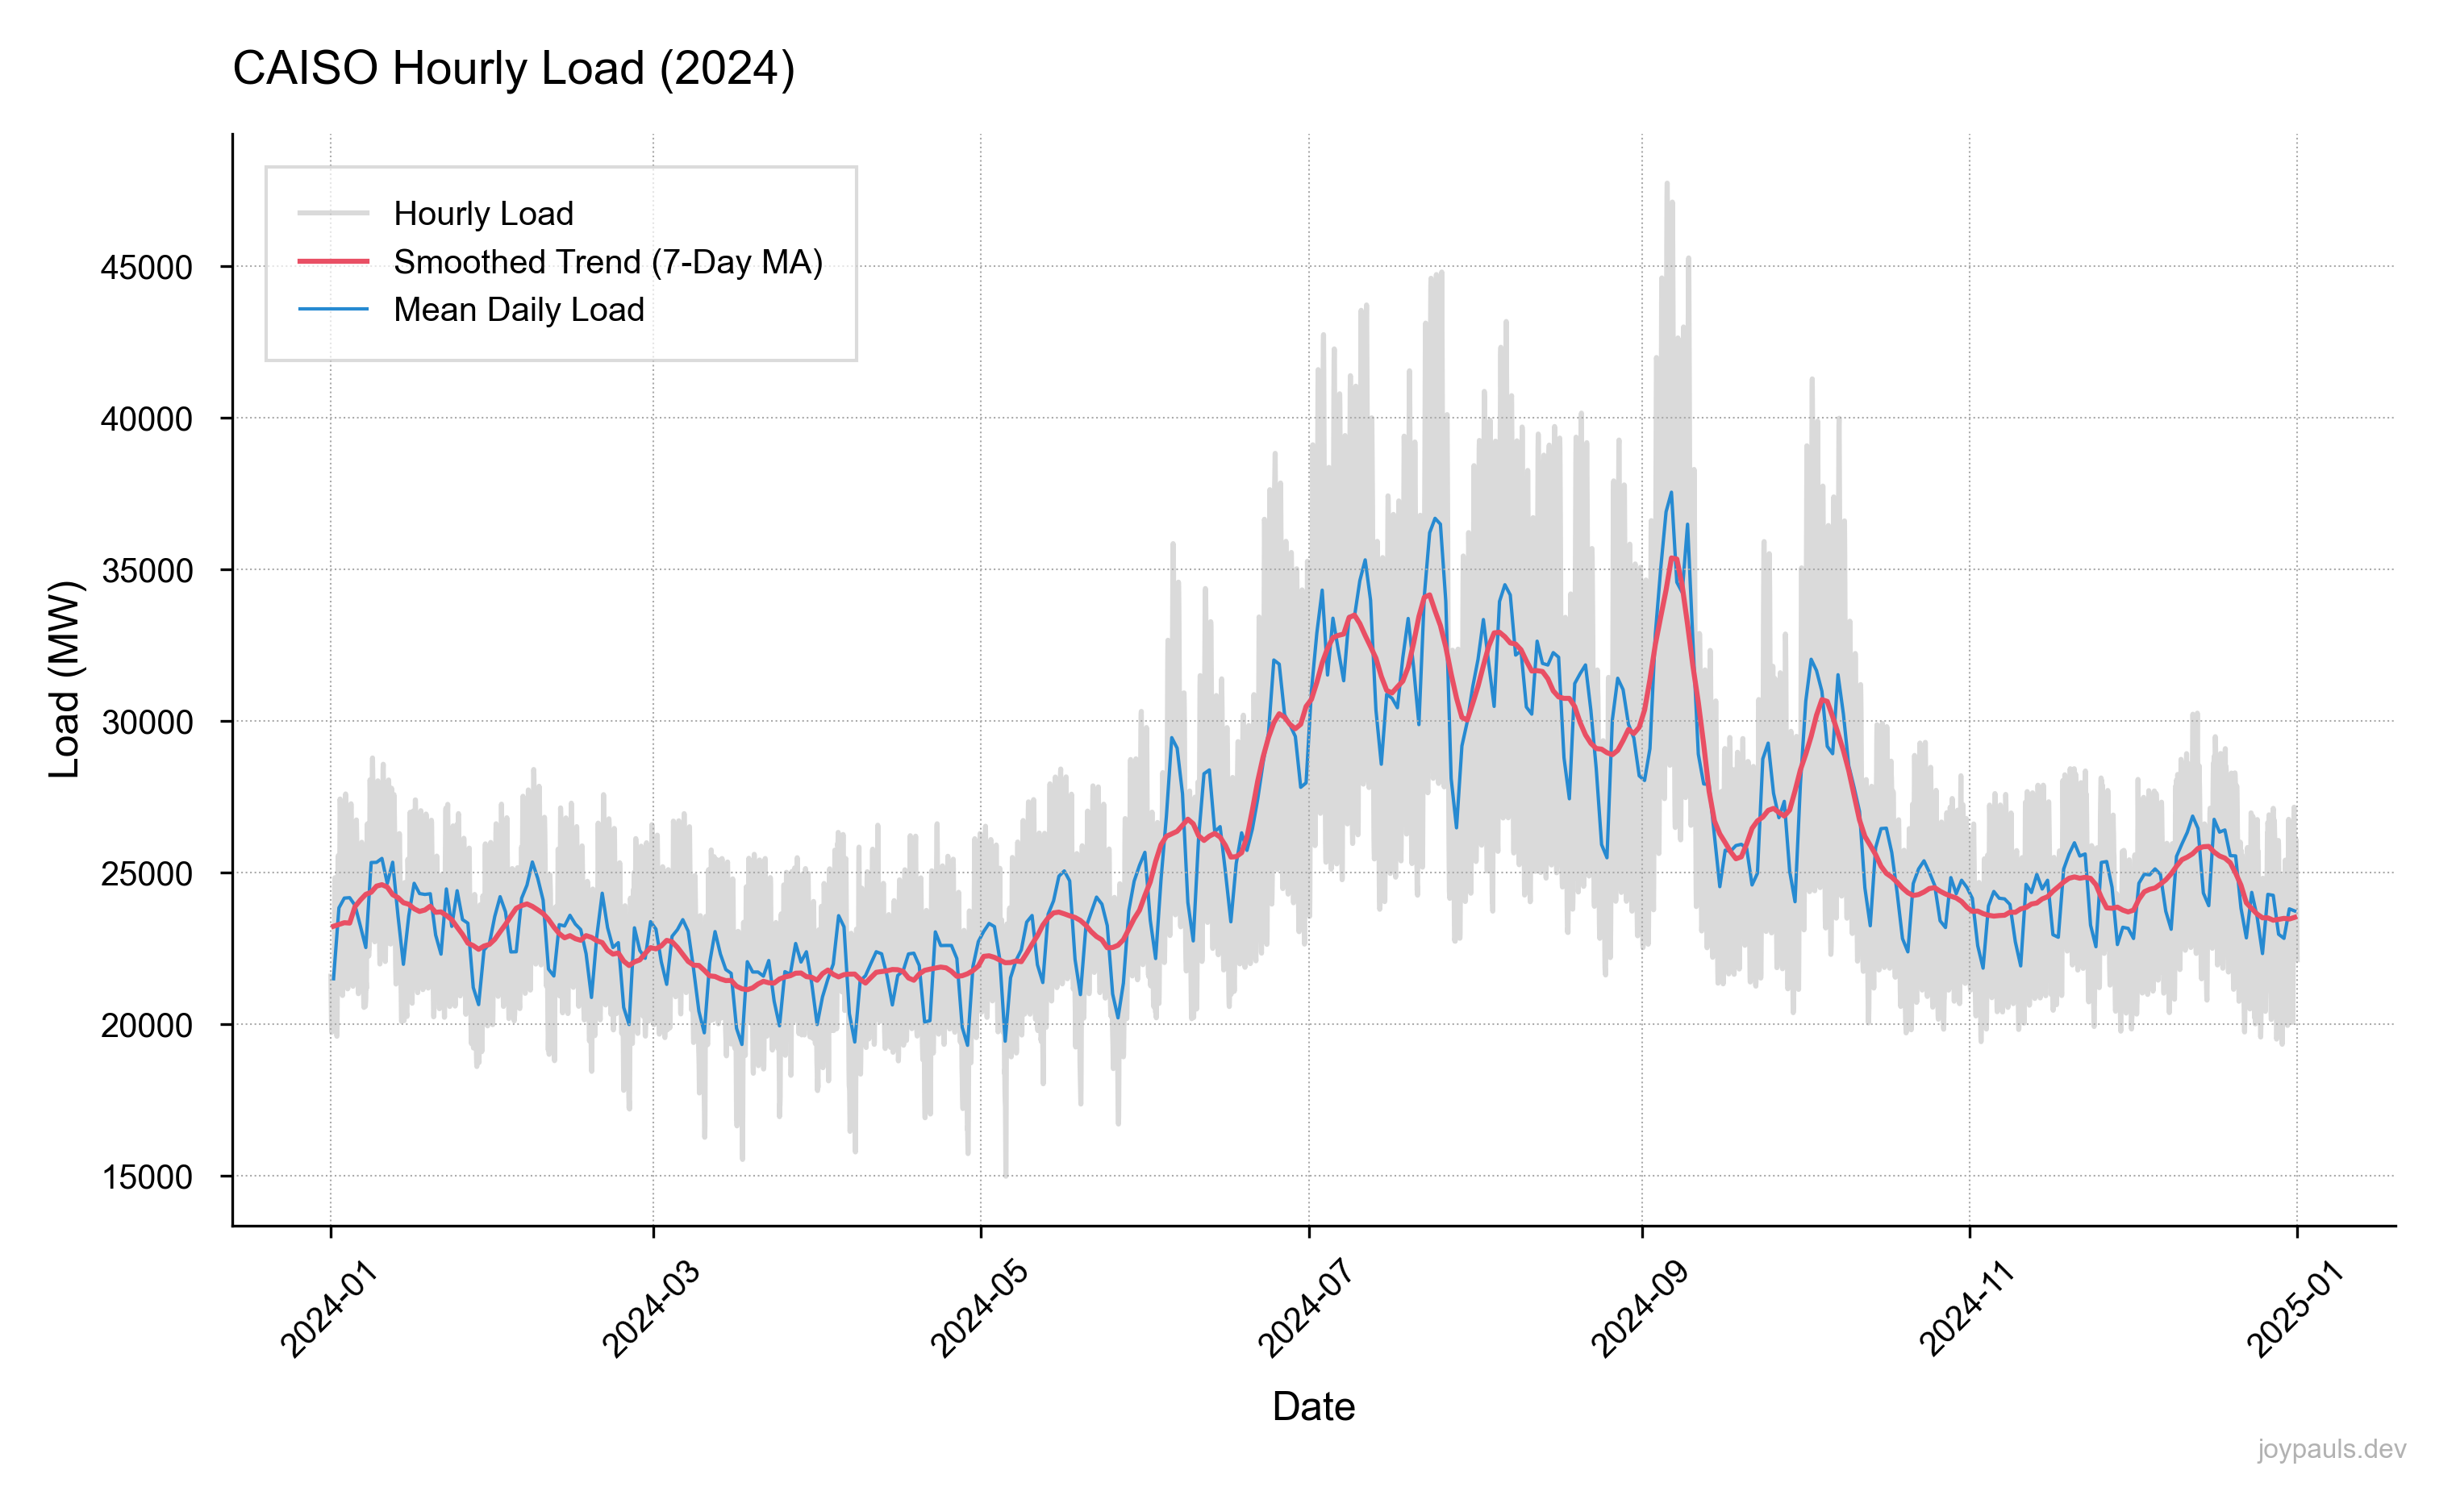

In [183]:
df_2024_daily = df_daily[df_daily["datetime"].dt.year == 2024].copy()

# plot line line chart
plt.figure(figsize=(10, 6))

plt.plot(df_2024["datetime"], df_2024["load"], alpha=0.2, label="Hourly Load", linewidth=1.5, zorder=0)
plt.plot(df_2024_daily["datetime"], df_2024_daily["load_ma"], label="Smoothed Trend (7-Day MA)", linewidth=1.5, zorder=2)
plt.plot(df_2024_daily["datetime"], df_2024_daily["load"], label="Mean Daily Load", linewidth=1, color="#268ad1", linestyle="solid", zorder=1)

plt.title("CAISO Hourly Load (2024)", loc="left", fontweight="regular")
plt.xlabel("Date", labelpad=8)
plt.ylabel("Load (MW)")
plt.xticks(rotation=45)
plt.legend(loc="upper left", frameon=True, fontsize=10, framealpha=0.7, borderpad=1, fancybox=False)

plt.tick_params(axis="x", pad=5)
plt.gcf().text(0.99, 0.00, "joypauls.dev", ha="right", va="bottom", fontsize=8, color="gray", alpha=0.6)

plt.savefig("../../joypauls.dev-astro/src/assets/blog/caiso-electricity-demand/single_year.png")
plt.show()

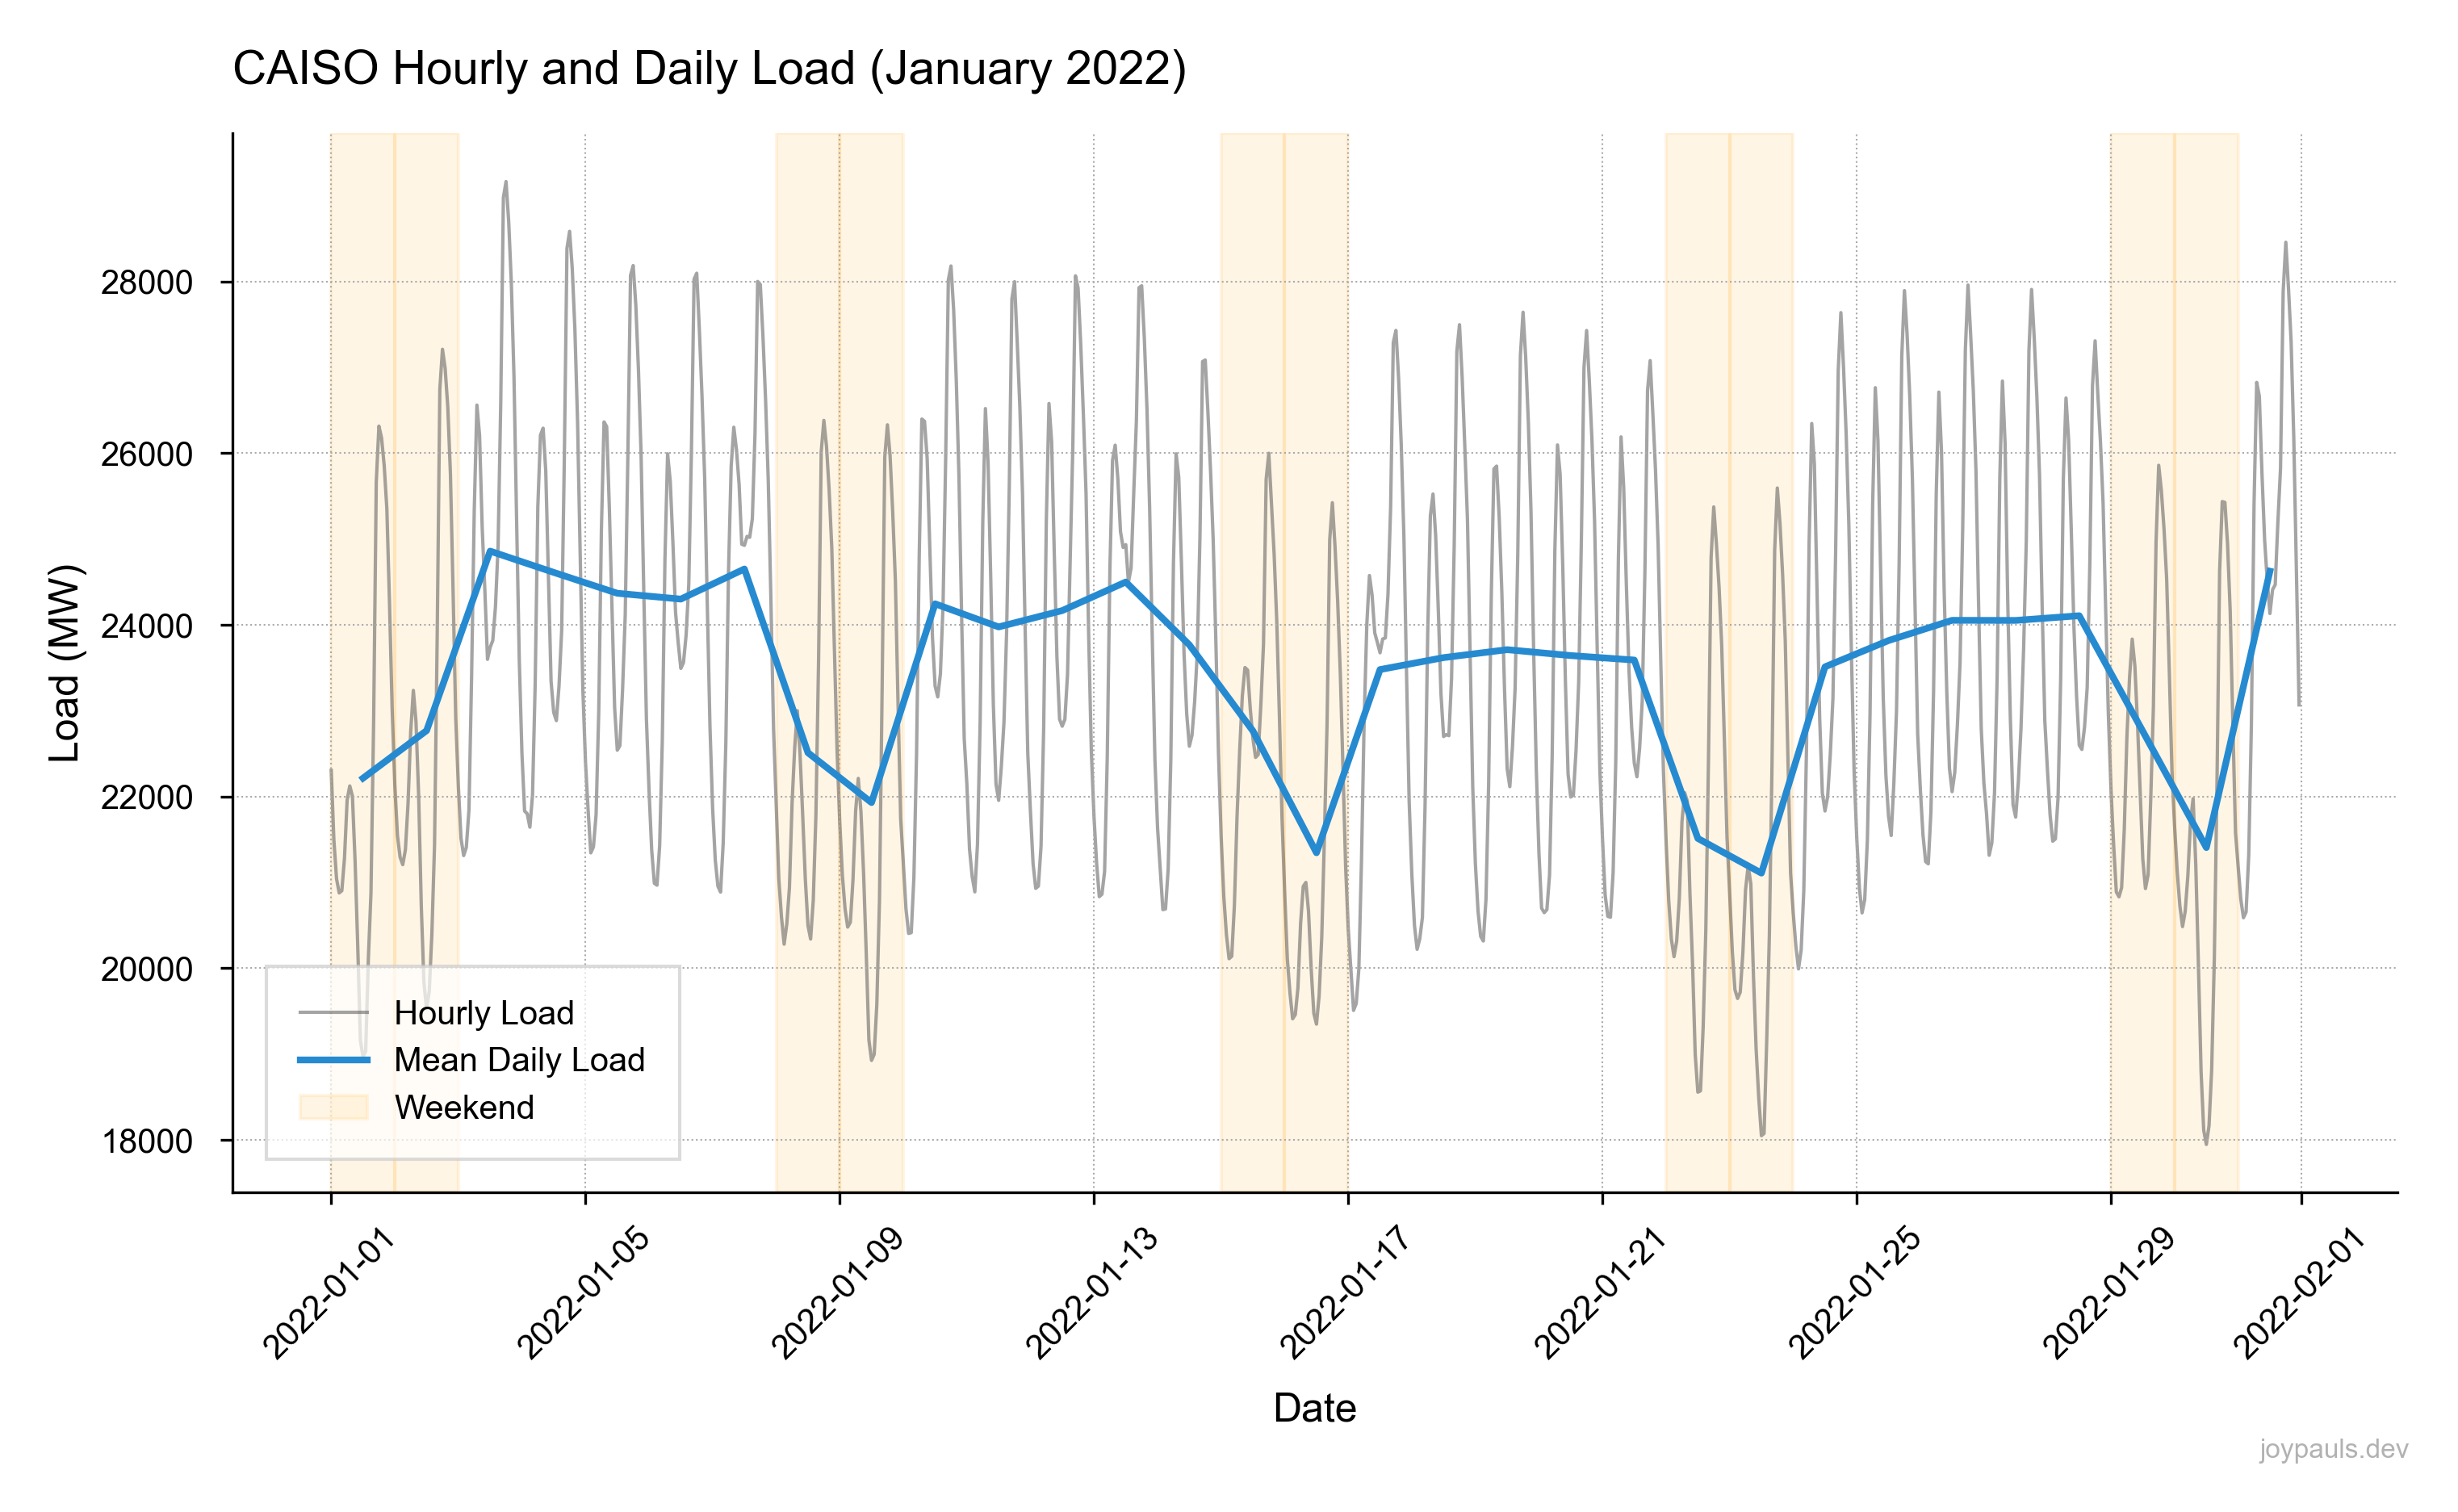

In [173]:
df_2022_daily = df_daily[df_daily["datetime"].dt.year == 2022].copy()
df_2022_jan_daily = df_2022_daily[df_2022_daily["datetime"].dt.month == 1].copy()
df_2022_jan = df_2022[df_2022["datetime"].dt.month == 1].copy()

# plot line line chart
plt.figure(figsize=(10, 6))

plt.plot(df_2022_jan["datetime"], df_2022_jan["load"], alpha=0.5, label="Hourly Load", linewidth=1, zorder=1)
plt.plot(df_2022_jan_daily["datetime"], df_2022_jan_daily["load"], label="Mean Daily Load", linewidth=2, color="#268ad1", linestyle="solid", zorder=2)

# highlight weekends
for i in range(len(df_2022_jan_daily)):
    if df_2022_jan_daily["dow"].iloc[i] > 4:  # Saturday or Sunday
        plt.axvspan(df_2022_jan_daily["datetime"].iloc[i] - pd.Timedelta(hours=12),
                    df_2022_jan_daily["datetime"].iloc[i] + pd.Timedelta(hours=12),
                    color="orange", alpha=0.1, label="Weekend" if i == 0 else "", zorder=0)

plt.title("CAISO Hourly and Daily Load (January 2022)", loc="left", fontweight="regular")
plt.xlabel("Date", labelpad=8)
plt.ylabel("Load (MW)")
plt.xticks(rotation=45)
plt.legend(loc="lower left", frameon=True, fontsize=10, framealpha=0.7, borderpad=1, fancybox=False)

plt.tick_params(axis="x", pad=5)
plt.gcf().text(0.99, 0.001, "joypauls.dev", ha="right", va="bottom", fontsize=8, color="gray", alpha=0.6)

plt.savefig("../../joypauls.dev-astro/src/assets/blog/caiso-electricity-demand/single_month.png")
plt.show()

In [174]:
# group by hour calculate mean load
df_2024_hour_avg = df_2024.groupby(["hour"])["load"].mean().reset_index()

df_2024_hour_avg.head()

,hour,load
0,0,23814.201059
1,1,22909.592042
2,2,22213.706537
3,3,21826.283645
4,4,21821.913086


In [175]:
# # group by hour and month and calculate mean load
# df_2024_month_avg = df_2024.groupby(["month", "hour"])["load"].mean().reset_index()

# df_2024_month_avg.head()

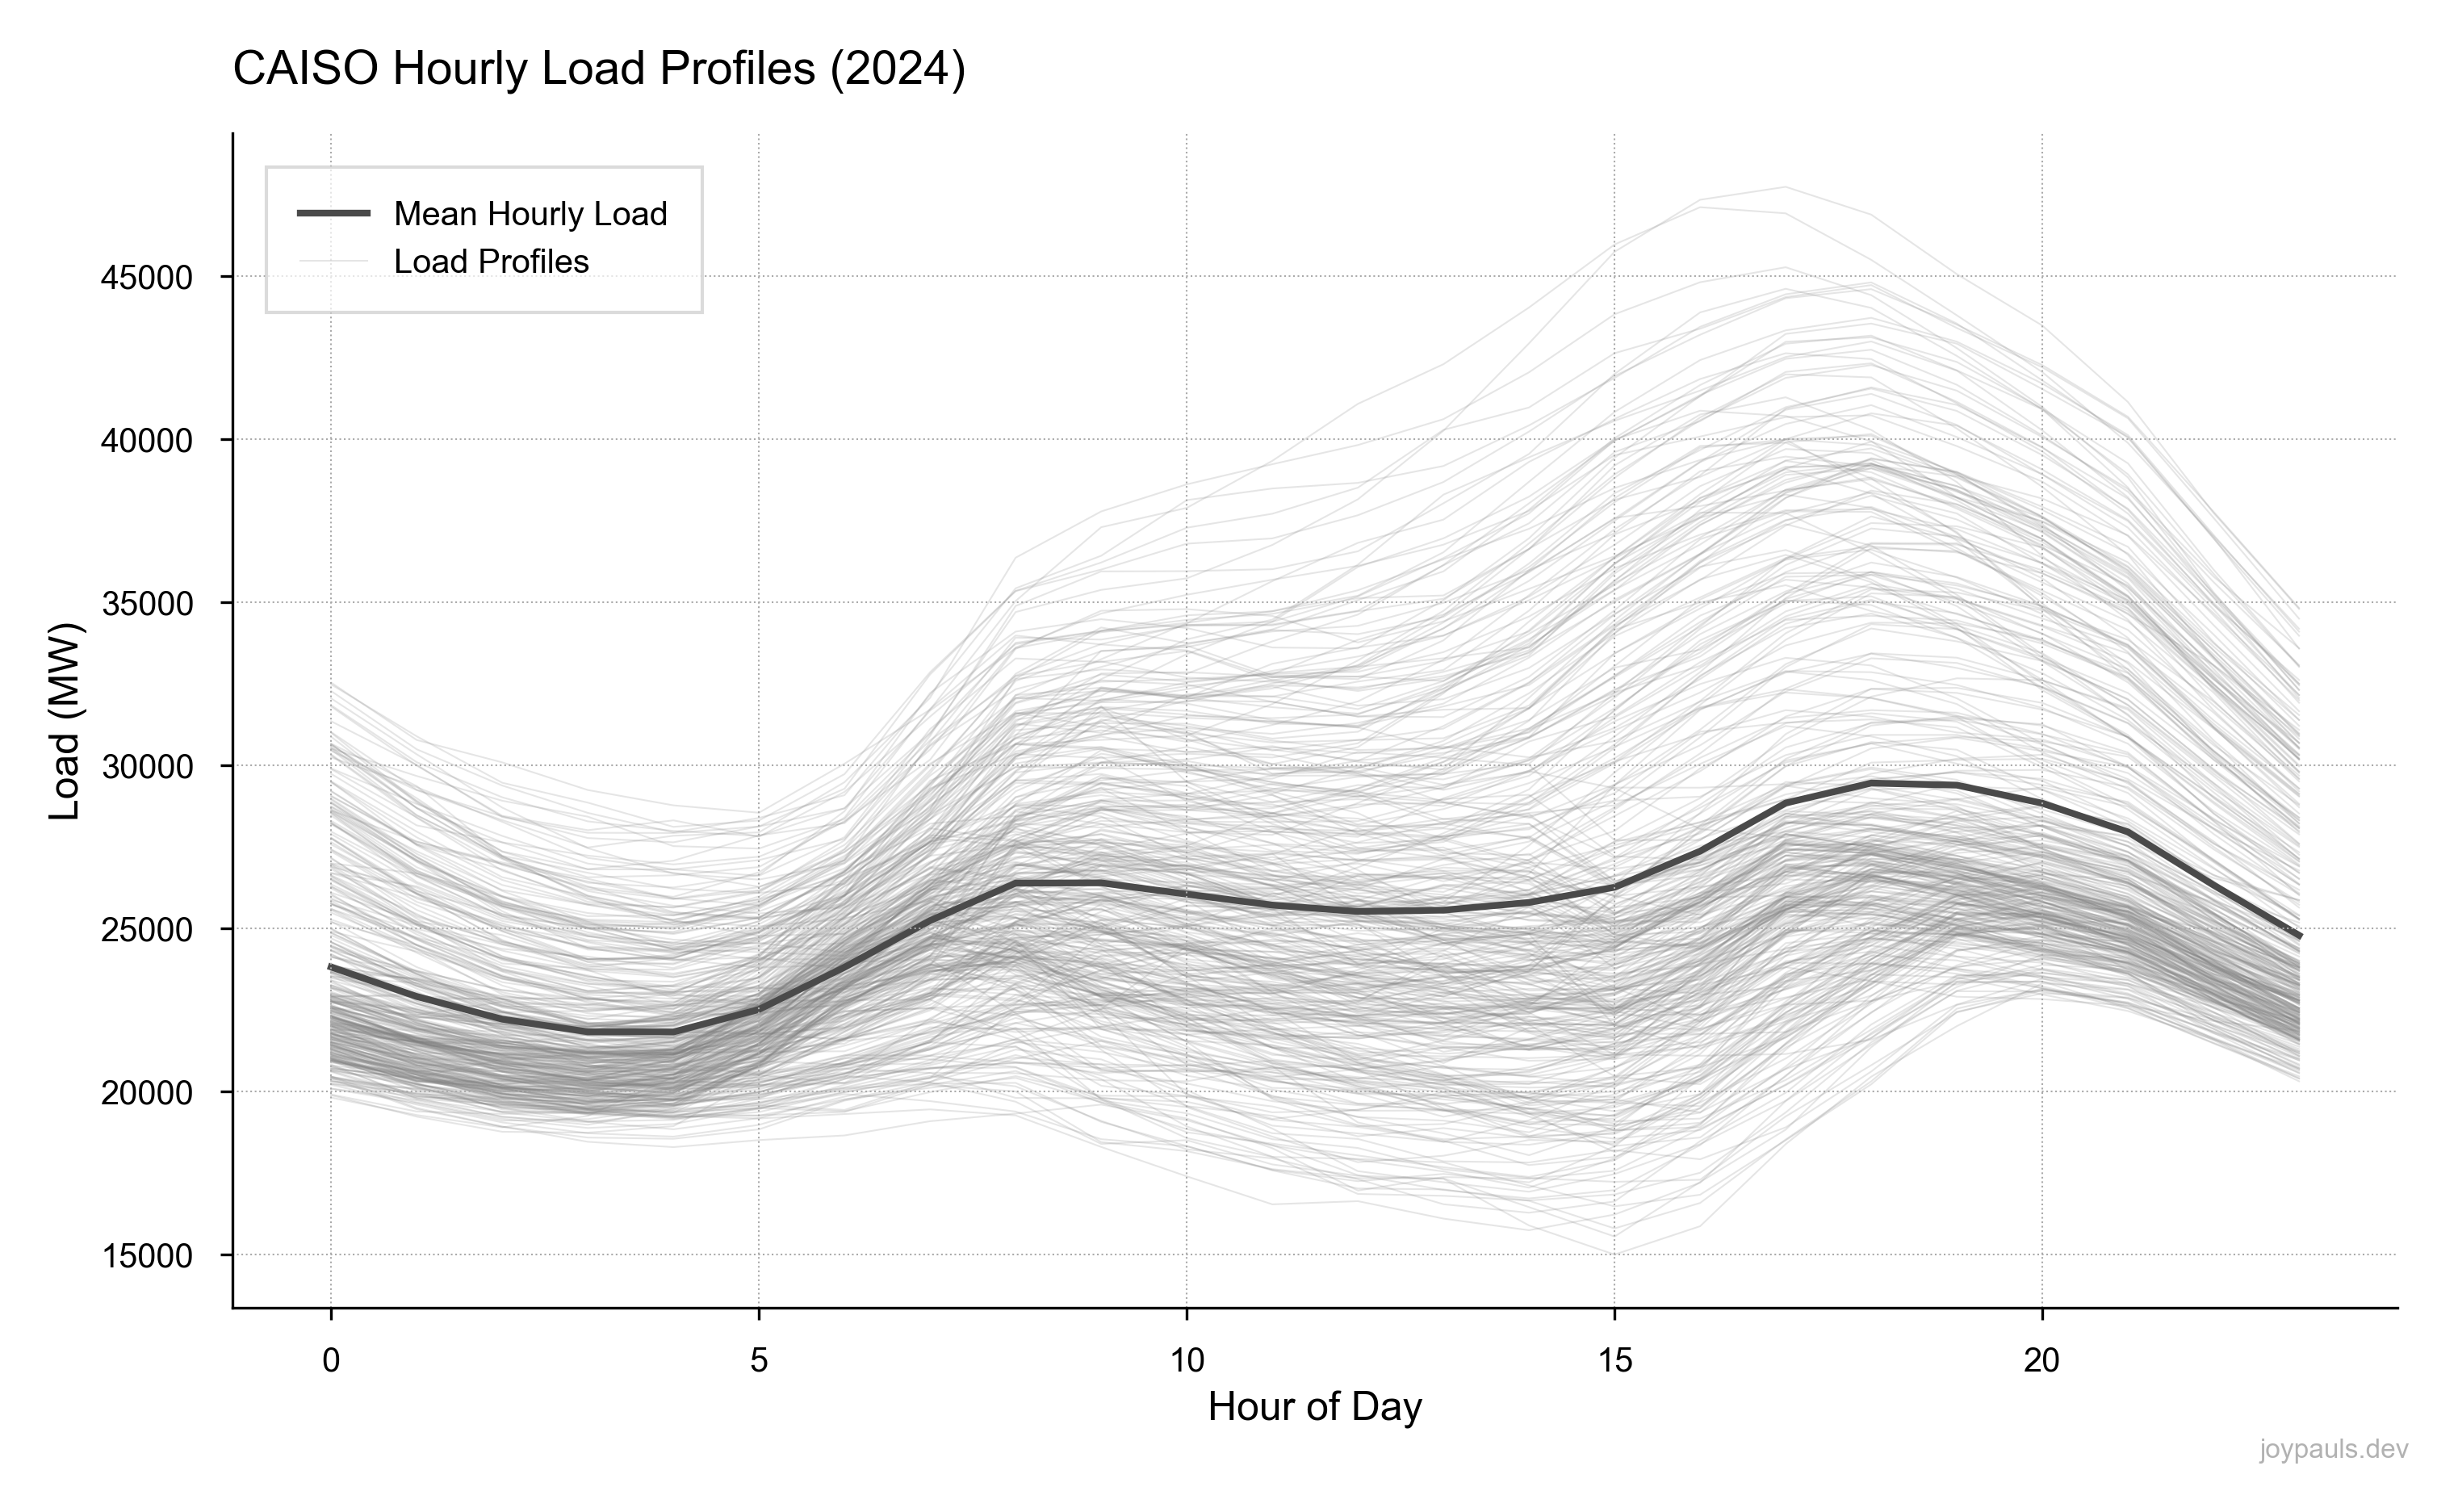

In [176]:
# line plot of average load by hour
plt.figure(figsize=(10, 6))
# plt.scatter(df["hour"], df["CAISO"], alpha=0.2, zorder = 0)

plt.plot(df_2024_hour_avg["hour"], df_2024_hour_avg["load"], label="Mean Hourly Load", linewidth=2, zorder = 1)

# plot all other days 
for month in df_2024["date"].unique():
    month_data = df_2024[df_2024["date"] == month]
    plt.plot(month_data["hour"], month_data["load"], alpha=0.2, color="gray", linewidth=0.5, zorder=0, label="Load Profiles" if month == df_2024["date"].unique()[0] else "")

plt.title("CAISO Hourly Load Profiles (2024)", loc="left", fontweight="regular")
plt.xlabel("Hour of Day")
plt.ylabel("Load (MW)")
plt.legend(loc="upper left", frameon=True, fontsize=10, framealpha=0.7, borderpad=1, fancybox=False)

plt.gcf().text(0.99, 0.001, "joypauls.dev", ha="right", va="bottom", fontsize=8, color="gray", alpha=0.6)

plt.savefig("../../joypauls.dev-astro/src/assets/blog/caiso-electricity-demand/load_profiles.png")
plt.show()


# # line plot of average load by hour
# plt.figure(figsize=(10, 6))
# # plt.scatter(df["hour"], df["CAISO"], alpha=0.2, zorder = 0)
# plt.plot(df_2024_hour_avg["hour"], df_2024_hour_avg["load"], label="Average Hourly Load", marker="o", linewidth=2, zorder = 1, markersize=0)
# plt.scatter([8, 18], df_2024_hour_avg[df_2024_hour_avg["hour"].isin([8, 18])]["load"], color="red", marker="s", s=100, alpha=1.0, label="Peak Hours (8 AM, 6 PM)", zorder = 2)

# plt.title("Mean Hourly Load in 2024", loc="left", fontweight="regular")
# plt.xlabel("Hour of Day")
# plt.ylabel("Load (MW)")
# plt.legend(loc="upper left", frameon=True, fontsize=10, framealpha=0.7, borderpad=1, fancybox=False)
# plt.show()


In [177]:
df_year_hour_avg = df.groupby(["year", "hour"])["load"].mean().reset_index()

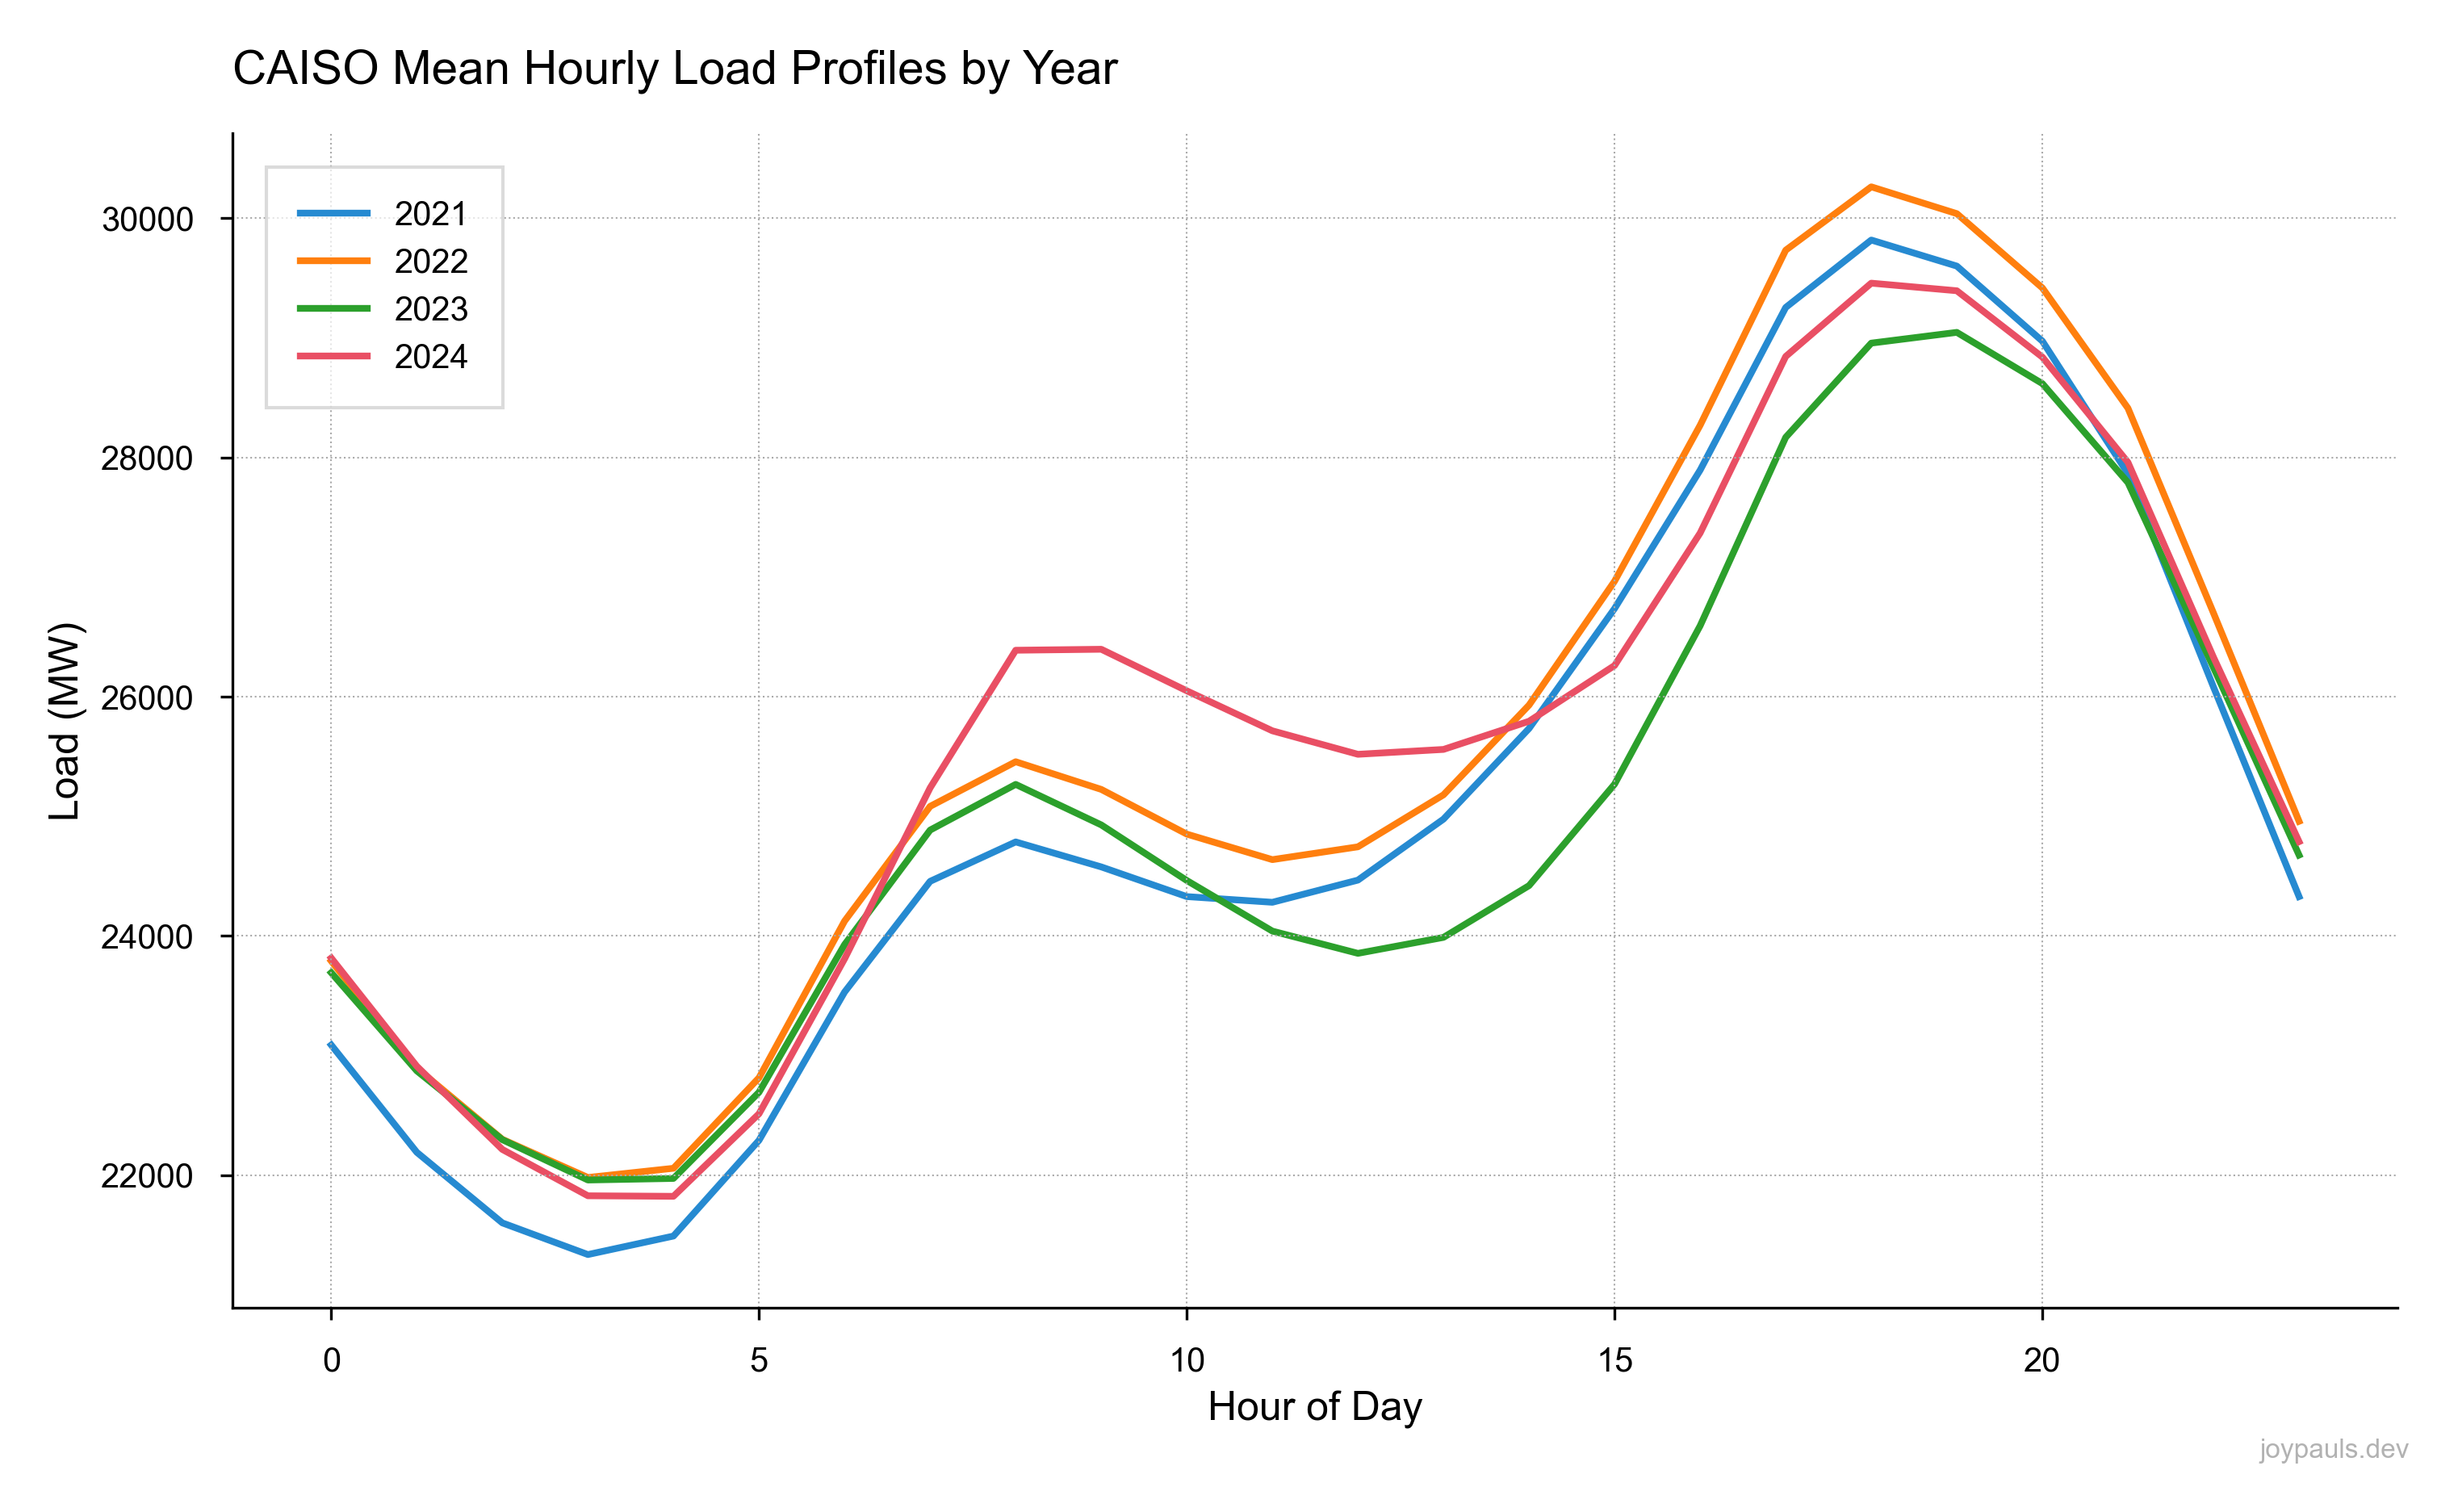

In [178]:
# line plot of average load by hour
plt.figure(figsize=(10, 6))

colors = {2021: "#268ad1", 2022: "#ff7f0e", 2023: "#2ca02c", 2024: "#e94f64"}

for year in df_year_hour_avg["year"].unique():
    if year == 2025:
        continue
    year_data = df_year_hour_avg[df_year_hour_avg["year"] == year]
    plt.plot(year_data["hour"], year_data["load"], label=f"{year}", linewidth=2, zorder = 1, color=colors[year])

# plt.plot(df_2024_hour_avg["hour"], df_2024_hour_avg["load"], label="Average Hourly Load", marker="o", linewidth=2, zorder = 1, markersize=0)
# plt.scatter([8, 18], df_2024_hour_avg[df_2024_hour_avg["hour"].isin([8, 18])]["load"], color="red", marker="s", s=100, alpha=1.0, label="Peak Hours (8 AM, 6 PM)", zorder = 2)

plt.title("CAISO Mean Hourly Load Profiles by Year", loc="left", fontweight="regular")
plt.xlabel("Hour of Day")
plt.ylabel("Load (MW)")
plt.legend(loc="upper left", frameon=True, fontsize=10, framealpha=0.7, borderpad=1, fancybox=False)

plt.gcf().text(0.99, 0.001, "joypauls.dev", ha="right", va="bottom", fontsize=8, color="gray", alpha=0.6)

plt.savefig("../../joypauls.dev-astro/src/assets/blog/caiso-electricity-demand/load_profiles_by_year.png")
plt.show()

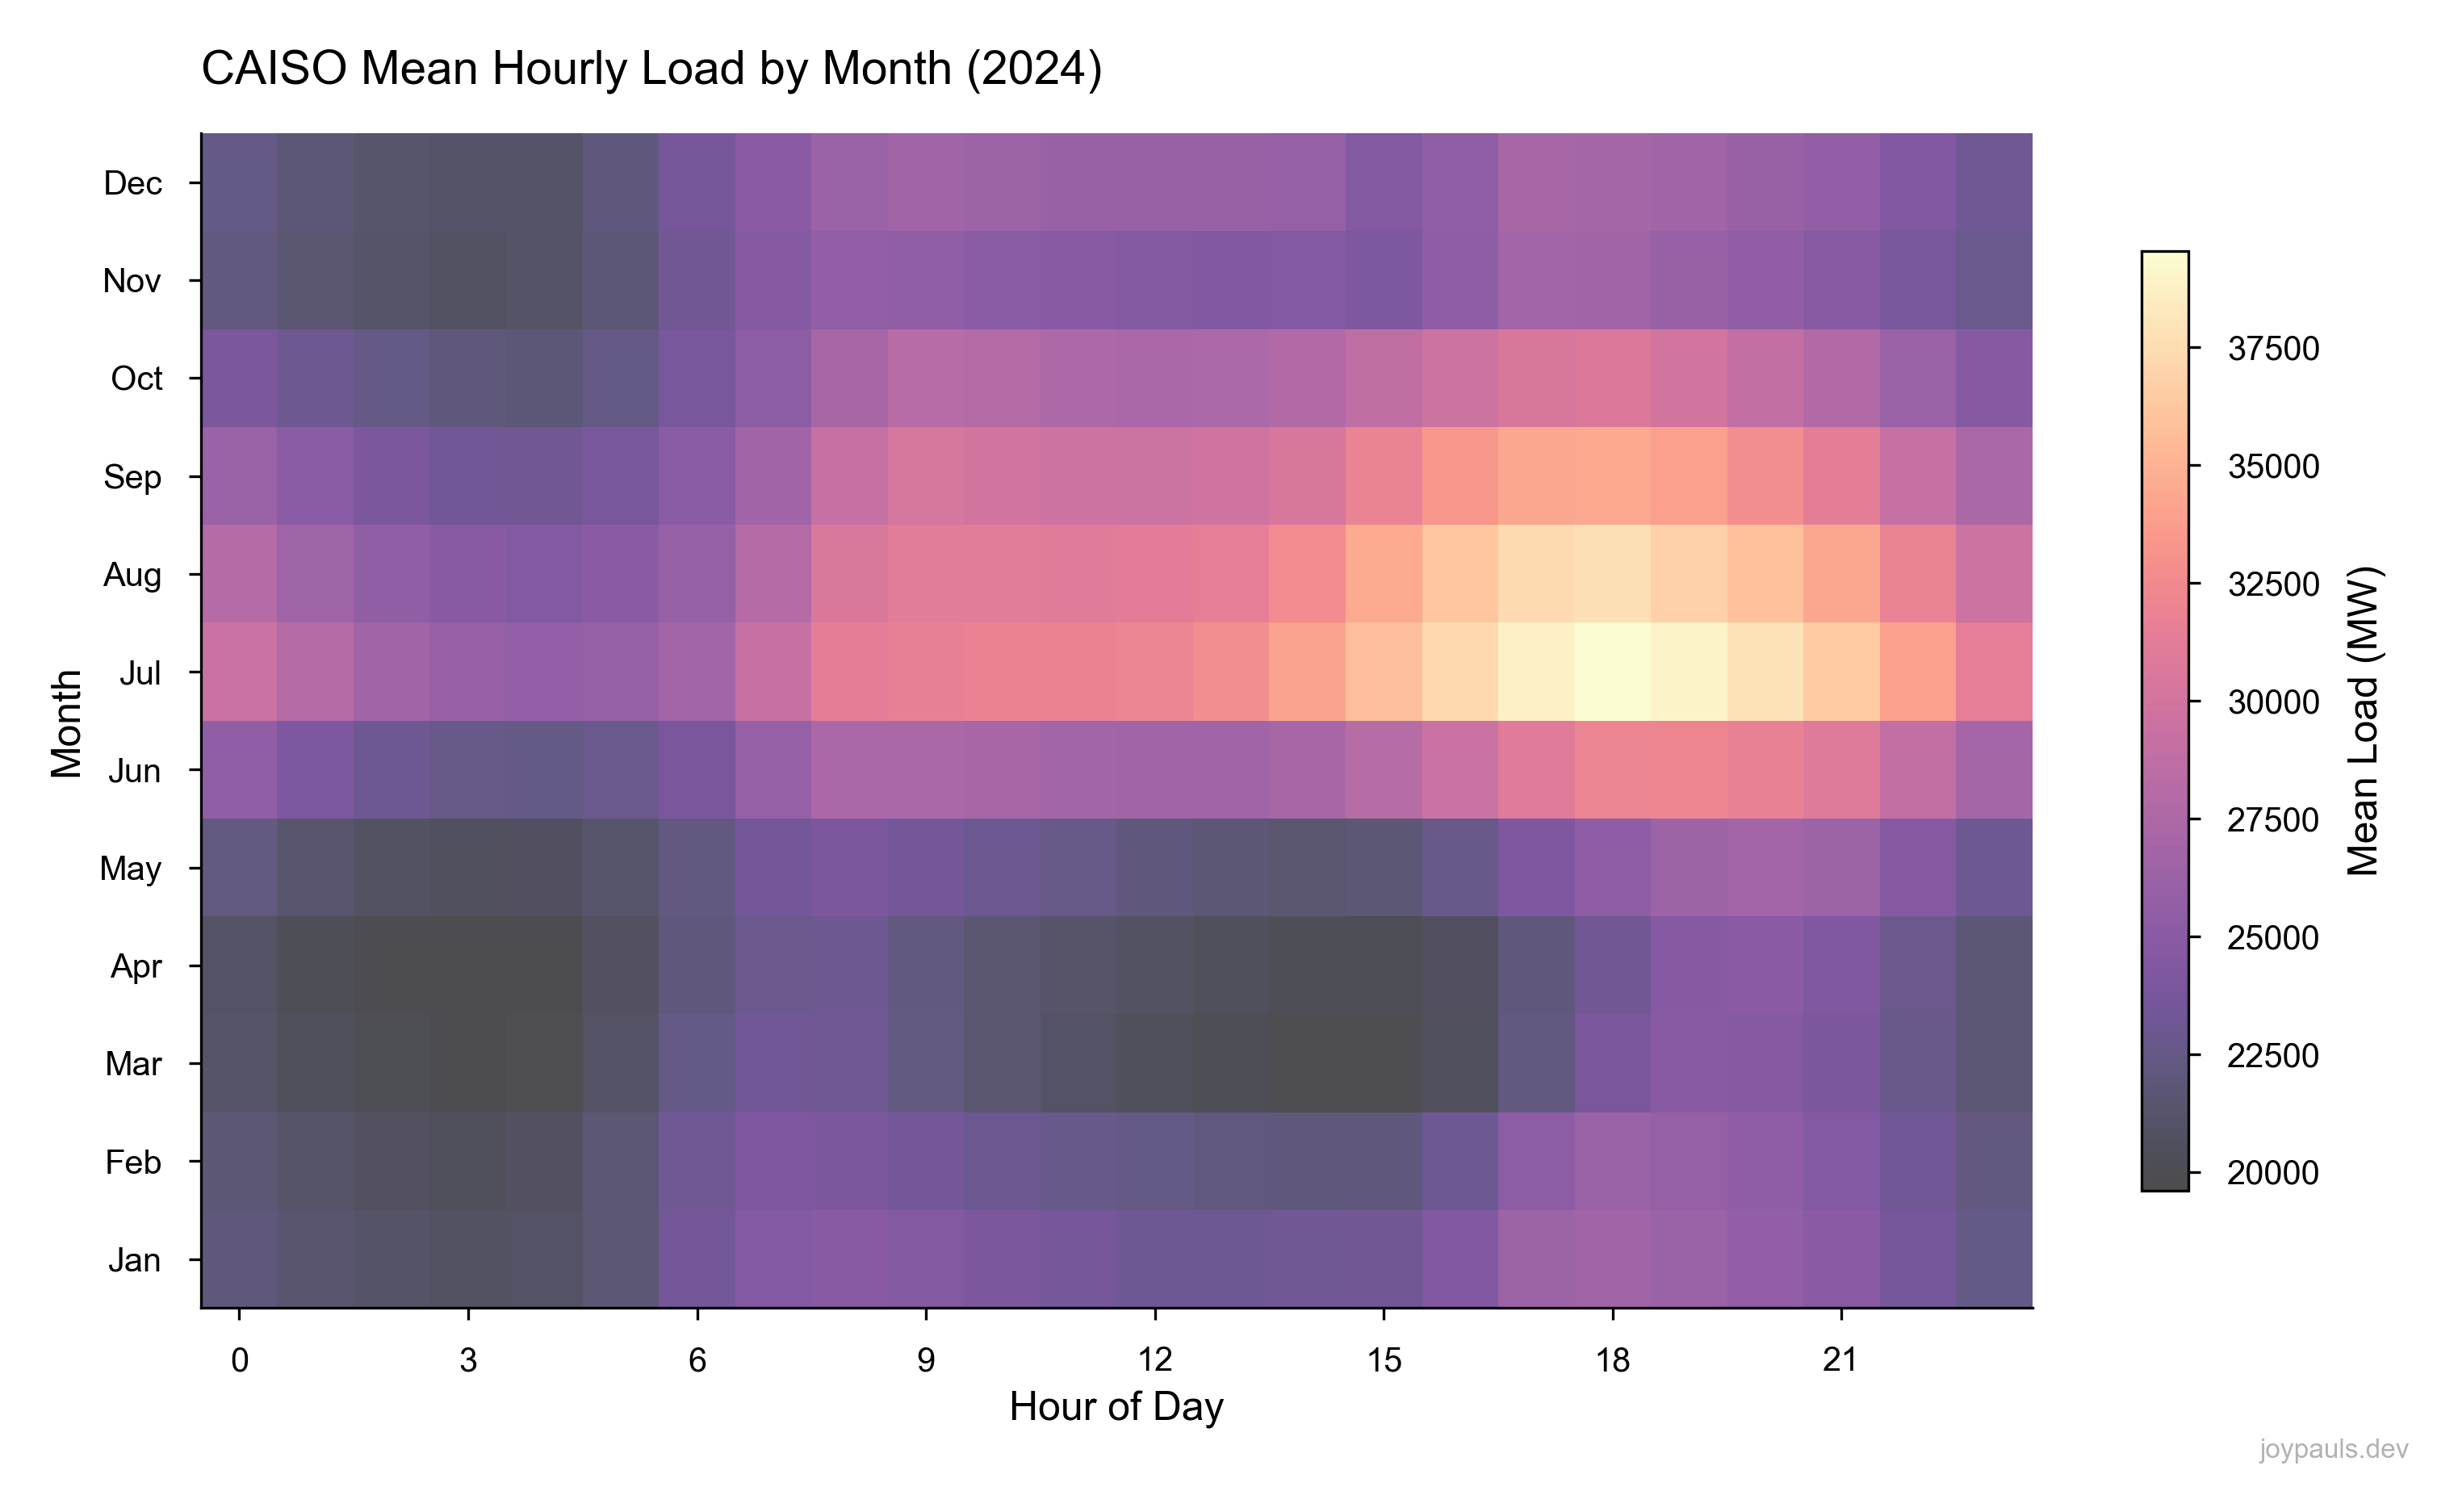

In [179]:


df_2024["hour"] = df_2024["datetime"].dt.hour
df_2024["doy"] = df_2024["datetime"].dt.dayofyear
df_2024["month"] = df_2024["datetime"].dt.month

heatmap_data = df_2024.pivot_table(
    index="month",
    columns="hour",
    values="load",
    aggfunc="mean"
)

# Plotting
plt.figure(figsize=(10, 6))
plt.imshow(heatmap_data, aspect="auto", cmap="magma", origin="lower", alpha=0.7)
cb = plt.colorbar(label="Mean Load (MW)", pad=0.05, fraction=0.11, shrink=0.8)
cb.set_label("Mean Load (MW)", labelpad=8)
plt.xlabel("Hour of Day")
plt.ylabel("Month")
plt.title("CAISO Mean Hourly Load by Month (2024)", loc="left", fontweight="regular")

plt.xticks(np.arange(0, 24, 3))
plt.yticks(np.arange(12), labels=[
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
])

plt.grid(False) 
plt.tight_layout()

plt.gcf().text(0.99, 0.001, "joypauls.dev", ha="right", va="bottom", fontsize=8, color="gray", alpha=0.6)

plt.savefig("../../joypauls.dev-astro/src/assets/blog/caiso-electricity-demand/heatmap.png")
plt.show()


In [180]:
# print indices of min/max of heatmap_data
print(np.unravel_index(np.argmin(heatmap_data.values), heatmap_data.shape))
print(np.unravel_index(np.argmax(heatmap_data.values), heatmap_data.shape))

(3, 3)
(6, 18)
